<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [20]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])

In [21]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

X_numeric = df[X].select_dtypes(include=["number"]).columns.tolist()

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>3</small>&nbsp;&nbsp;&nbsp;&nbsp; SCM:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">

<div style="text-align: align;">
  <h3> <small>3.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Preparing Brazil:</h3>
</div>

In [25]:
def scm1(df, country, treat_year):

    df = df.sort_values(["Country Name", "Year"]).copy()

    # Periods
    years = sorted(df["Year"].unique())
    pre_years = [y for y in years if y < treat_year]
    post_years = [y for y in years if y >= treat_year]

    # Matrix form
    Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

    # Keep complete pre-period countries
    pre_mask = Y.loc[pre_years].notna().all(axis=0)
    Y = Y.loc[:, pre_mask]

    # Check treated unit
    if country not in Y.columns:
        raise ValueError(
            f"Error: {country} not in columns after cleaning. "
            f"Available: {list(Y.columns)[:10]}..."
        )

    # Split treated / donors
    donors = [c for c in Y.columns if c != country]
    Y1 = Y[country]
    Y0 = Y[donors]

    # Pre-treatment data
    X1 = Y0.loc[pre_years].values
    y1 = Y1.loc[pre_years].values

    # =========================
    # OPTIMIZATION
    # =========================
    w = cp.Variable(len(donors))
    objective = cp.Minimize(cp.sum_squares(y1 - X1 @ w))
    constraints = [w >= 0, cp.sum(w) == 1]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    if w.value is None:
        raise RuntimeError("Optimization failed.")

    w_hat = np.array(w.value).ravel()

    # =========================
    # PREFIT DIAGNOSTICS
    # =========================
    pre_residuals = y1 - X1 @ w_hat

    pre_sse = np.sum(pre_residuals ** 2)
    pre_rmse = np.sqrt(np.mean(pre_residuals ** 2))

    # =========================
    # SYNTHETIC + EFFECT
    # =========================
    synthetic = Y0.values @ w_hat
    synthetic = pd.Series(synthetic, index=Y.index, name=f"Synthetic {country}")

    effect = Y1 - synthetic

    # Weights
    weights = pd.Series(w_hat, index=donors).sort_values(ascending=False)

    return {
        "country": country,
        "weights": weights,
        "synthetic": synthetic,
        "effect": effect,
        "pre_sse": pre_sse,
        "pre_rmse": pre_rmse,
        "pre_residuals": pre_residuals,
    }

In [26]:
brazil_scm = scm1(df, "Brazil", 1996)

print("Pre-treatment RMSE:", brazil_scm["pre_rmse"])
print("Top weights:\n", brazil_scm["weights"].head(10))

Pre-treatment RMSE: 0.020093414326047637
Top weights:
 Madagascar     7.521741e-01
Thailand       2.478259e-01
Finland        2.625052e-19
Netherlands    2.439220e-19
Hungary        2.378377e-19
Norway         2.359658e-19
Australia      2.239122e-19
Iceland        2.212409e-19
Italy          2.180912e-19
Sweden         2.178890e-19
dtype: float64


In [27]:
us_scm = scm1(df, "United States", 2003)

print("Pre-treatment RMSE:", us_scm["pre_rmse"])
print("Top weights:\n", us_scm["weights"].head(10))

Pre-treatment RMSE: 0.004763222386900163
Top weights:
 Sri Lanka      3.290251e-01
Nepal          1.794558e-01
Germany        1.607500e-01
Luxembourg     1.488079e-01
Finland        9.891697e-02
Botswana       5.255359e-02
Philippines    3.049068e-02
Madagascar     6.003299e-19
Brazil         4.997828e-19
Iran           4.063009e-19
dtype: float64


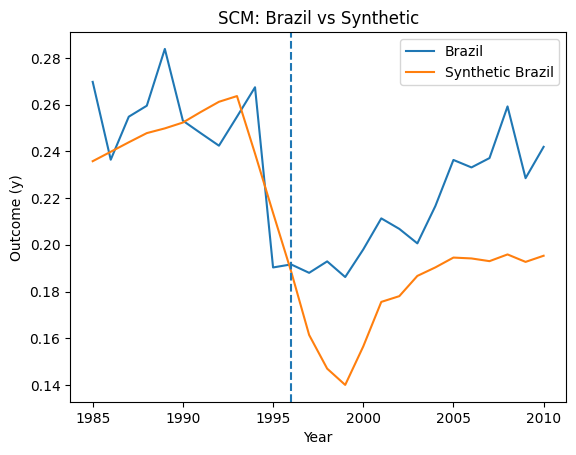

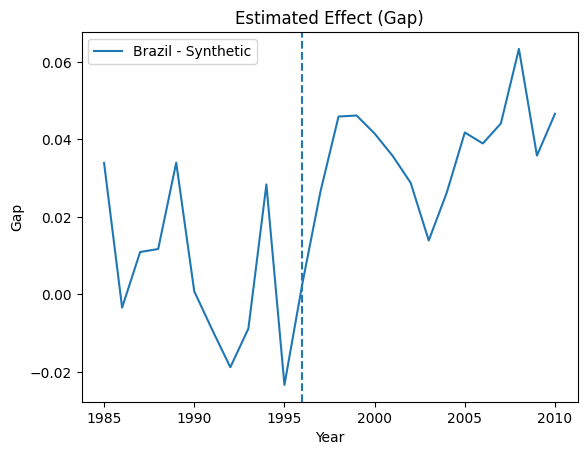

Top donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64


In [1]:
df = df[(df['Year'] >= 1985) & (df['Year'] <= 2015)]
treated_unit = "Brazil"
treat_year = 1996  

# Keep a balanced-ish panel for SCM years
years = sorted(df["Year"].unique())
pre_years = [y for y in years if y < treat_year]
post_years = [y for y in years if y >= treat_year]

# Pivot to matrix: rows=years, cols=countries
Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

# Drop countries with missing values in the pre-period (simple, conservative)
pre_mask = Y.loc[pre_years].notna().all(axis=0)
Y = Y.loc[:, pre_mask]

if treated_unit not in Y.columns:
    raise ValueError(f"{treated_unit} not in columns after cleaning. Available: {list(Y.columns)[:10]}...")

donors = [c for c in Y.columns if c != treated_unit]
Y1 = Y[treated_unit]          # Brazil series (all years)
Y0 = Y[donors]                # donor matrix (all years)

# Pre-treatment matrices for fitting weights
X1 = Y0.loc[pre_years].values  # donors in pre
y1 = Y1.loc[pre_years].values  # brazil in pre

# -----------------------
# 2) SCM OPTIMIZATION
#    Choose weights w to match pre-treatment path
#    min ||y1 - X1 w||^2
#    s.t. w>=0, sum(w)=1
# -----------------------
w = cp.Variable(len(donors))

objective = cp.Minimize(cp.sum_squares(y1 - X1 @ w))
constraints = [w >= 0, cp.sum(w) == 1]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)  # OSQP usually works well; try SCS if needed

if w.value is None:
    raise RuntimeError("Missing Data Error")

weights = pd.Series(np.array(w.value).ravel(), index=donors).sort_values(ascending=False)

# -----------------------
# 3) BUILD SYNTHETIC + EFFECT
# -----------------------
synthetic = (Y0.values @ np.array(w.value).ravel())
synthetic = pd.Series(synthetic, index=Y.index, name="Synthetic")

effect = Y1 - synthetic

# -----------------------
# 4) PLOTS
# -----------------------
plt.figure()
plt.plot(Y.index, Y1.values, label="Brazil")
plt.plot(Y.index, synthetic.values, label="Synthetic Brazil")
plt.axvline(treat_year, linestyle="--")
plt.title("SCM: Brazil vs Synthetic")
plt.xlabel("Year")
plt.ylabel("Outcome (y)")
plt.legend()
plt.show()

plt.figure()
plt.plot(effect.index, effect.values, label="Brazil - Synthetic")
plt.axvline(treat_year, linestyle="--")
plt.title("Estimated Effect (Gap)")
plt.xlabel("Year")
plt.ylabel("Gap")
plt.legend()
plt.show()

# -----------------------
# 5) OUTPUT TOP DONOR WEIGHTS
# -----------------------
print("Top donor weights:")
print(weights.head(15))

Countries to drop: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Brazil', 'Bulgaria', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Chad', 'Chile', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Cuba', 'DR Congo', 'Djibouti', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Georgia', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Iraq', 'Jamaica', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Lebanon', 'Liberia', 'Libya', 'Malawi', 'Maldives', 'Malta', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nicaragua', 'Oman', 'Palestine', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Qatar', 'Rwanda', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Seychelles', 'Sierra Leone', 'South Sudan', 'Sudan', 'Suriname', 'Syrian Arab Republic', 'Tajikistan', 'Timor-Leste', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkmeni

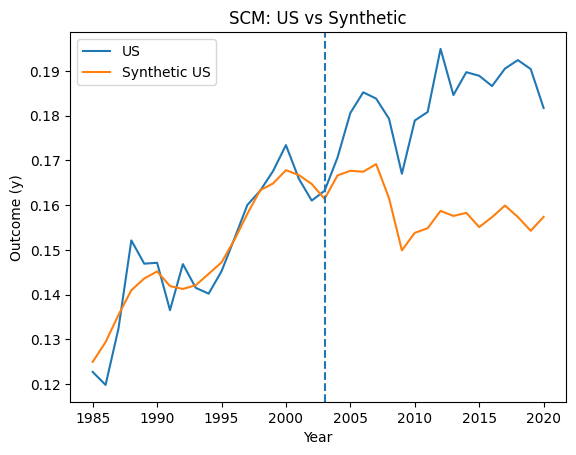

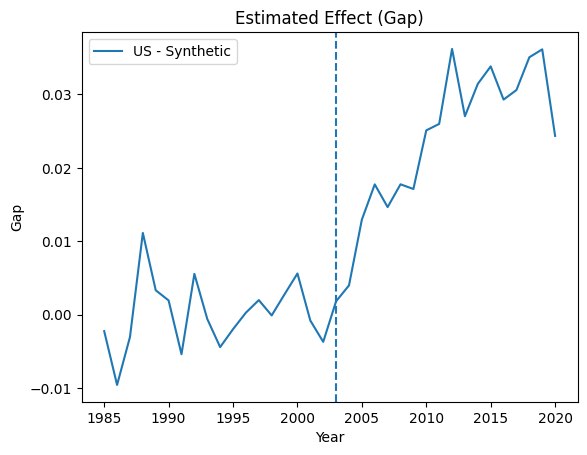

Top donor weights:
Sri Lanka             3.781993e-01
Germany               1.663113e-01
Nepal                 1.427078e-01
Finland               1.347237e-01
Luxembourg            1.107058e-01
Russian Federation    2.826250e-02
Malawi                2.493523e-02
Australia             1.415421e-02
Madagascar            9.282454e-19
Ethiopia              9.018890e-19
Eritrea               9.018890e-19
Indonesia             6.363539e-19
Ukraine               6.044803e-19
Peru                  5.884369e-19
Thailand              5.797697e-19
dtype: float64


In [2]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
# -----------------------
# 1) LOAD + PREP DATA
# -----------------------
df = pd.read_csv(path+ "scm_usa.csv")  # columns: country, year, y
eligible_countries = (
    df.loc[(df["Year"] <= 1985) & (df["top1_inc"].notna()), "Country Name"]
    .unique()
)
df = df[df["Country Name"].isin(eligible_countries)]
comparison = df[df['Year'].isin([1994, 1995])].pivot(index='Country Name', columns='Year', values='top1_inc')

countries_to_drop = comparison[comparison[1994] == comparison[1995]].index.tolist()

print("Countries to drop:", countries_to_drop)
df = df.sort_values(["Country Name", "Year"])
df = df[(df['Year'] >= 1985) & (df['Year'] <= 2020)]

treated_unit = "United States"
treat_year = 2003 # your treatment year

# Optional: drop problematic year(s)
# df = df[~df["year"].isin([1994, 1995])]

# Keep a balanced-ish panel for SCM years
years = sorted(df["Year"].unique())
pre_years = [y for y in years if y < treat_year]
post_years = [y for y in years if y >= treat_year]

# Pivot to matrix: rows=years, cols=countries
Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

# Drop countries with missing values in the pre-period (simple, conservative)
pre_mask = Y.loc[pre_years].notna().all(axis=0)
Y = Y.loc[:, pre_mask]

if treated_unit not in Y.columns:
    raise ValueError(f"{treated_unit} not in columns after cleaning. Available: {list(Y.columns)[:10]}...")

donors = [c for c in Y.columns if c != treated_unit]
Y1 = Y[treated_unit]          # Brazil series (all years)
Y0 = Y[donors]                # donor matrix (all years)

# Pre-treatment matrices for fitting weights
X1 = Y0.loc[pre_years].values  # donors in pre
y1 = Y1.loc[pre_years].values  # brazil in pre

# -----------------------
# 2) SCM OPTIMIZATION
#    Choose weights w to match pre-treatment path
#    min ||y1 - X1 w||^2
#    s.t. w>=0, sum(w)=1
# -----------------------
w = cp.Variable(len(donors))

objective = cp.Minimize(cp.sum_squares(y1 - X1 @ w))
constraints = [w >= 0, cp.sum(w) == 1]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)  # OSQP usually works well; try SCS if needed

if w.value is None:
    raise RuntimeError("Optimization failed. Try solver=cp.SCS or check missing data.")

weights = pd.Series(np.array(w.value).ravel(), index=donors).sort_values(ascending=False)

# -----------------------
# 3) BUILD SYNTHETIC + EFFECT
# -----------------------
synthetic = (Y0.values @ np.array(w.value).ravel())
synthetic = pd.Series(synthetic, index=Y.index, name="Synthetic")

effect = Y1 - synthetic

# -----------------------
# 4) PLOTS
# -----------------------
plt.figure()
plt.plot(Y.index, Y1.values, label="US")
plt.plot(Y.index, synthetic.values, label="Synthetic US")
plt.axvline(treat_year, linestyle="--")
plt.title("SCM: US vs Synthetic")
plt.xlabel("Year")
plt.ylabel("Outcome (y)")
plt.legend()
plt.show()

plt.figure()
plt.plot(effect.index, effect.values, label="US - Synthetic")
plt.axvline(treat_year, linestyle="--")
plt.title("Estimated Effect (Gap)")
plt.xlabel("Year")
plt.ylabel("Gap")
plt.legend()
plt.show()

# -----------------------
# 5) OUTPUT TOP DONOR WEIGHTS
# -----------------------
print("Top donor weights:")
print(weights.head(15))

In [3]:
print("Sum of ALL weights:", weights.sum())
print("Min weight:", weights.min())
print("Any negative weights?", (weights < -1e-10).any())
print("Sum of top 15 weights:", weights.head(15).sum())
print("Number of donors:", len(weights))
print("Number of ~zero weights (<1e-8):", (weights.abs() < 1e-8).sum())

Sum of ALL weights: 0.9999999999999997
Min weight: -3.796844935102542e-19
Any negative weights? False
Sum of top 15 weights: 0.9999999999999997
Number of donors: 200
Number of ~zero weights (<1e-8): 192


Pre-treatment RMSE (SCM):  0.0201
Pre-treatment RMSE (ASCM): 0.0194


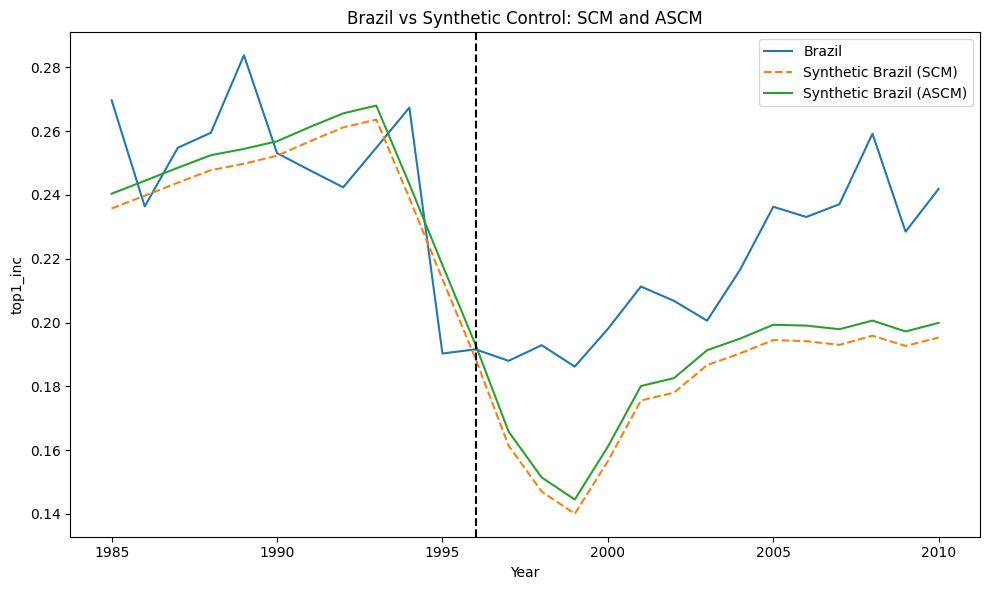

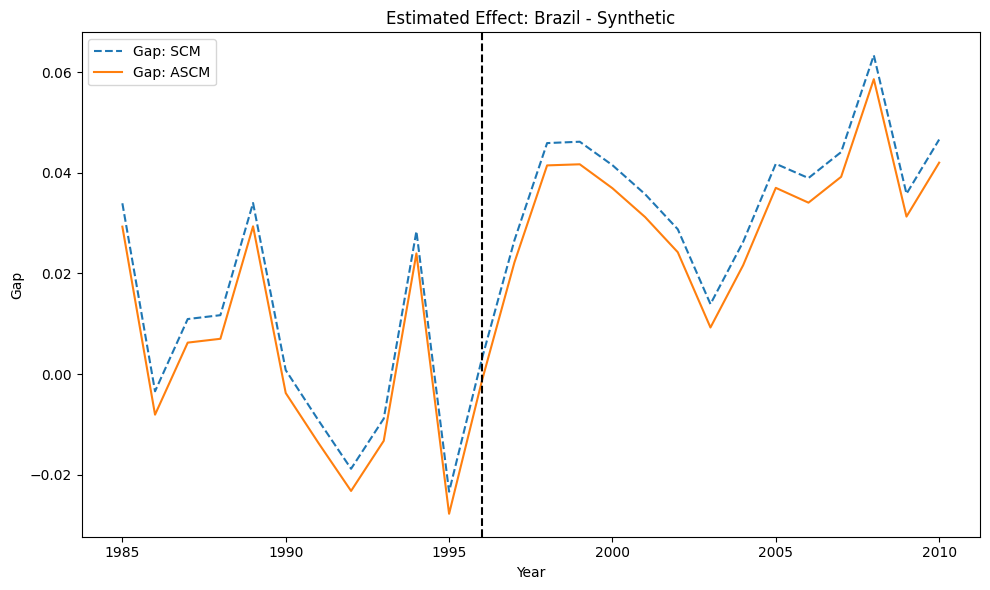


Top SCM donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64

Top ASCM donor weights:
Madagascar     0.753453
Thailand       0.249595
Iran           0.002348
Grenada        0.001675
Dominica       0.001675
Japan          0.001391
Switzerland    0.001367
Malaysia       0.001258
Sweden         0.001208
Germany        0.001178
Singapore      0.001101
Ghana          0.001071
Belgium        0.001015
Botswana       0.000947
Finland        0.000905
dtype: float64

ASCM weights can be negative:
Hungary           -0.001449
Nepal             -0.001342
New Zeala

In [1]:
path = '/Users/lucasdubois/Desktop/MASTERDATA/'

# -----------------------
# 1) LOAD + PREP DATA
# -----------------------
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])
df = df[(df["Year"] >= 1985) & (df["Year"] <= 2010)]

treated_unit = "Brazil"
treat_year = 1996

years = sorted(df["Year"].unique())
pre_years = [y for y in years if y < treat_year]
post_years = [y for y in years if y >= treat_year]

# Outcome matrix: rows = years, cols = countries
Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

# Keep only countries with full pre-treatment data
pre_mask = Y.loc[pre_years].notna().all(axis=0)
Y = Y.loc[:, pre_mask]

if treated_unit not in Y.columns:
    raise ValueError(f"{treated_unit} not in columns after cleaning.")

donors = [c for c in Y.columns if c != treated_unit]

Y1 = Y[treated_unit]     # treated series, all years
Y0 = Y[donors]           # donor matrix, all years

# Pre-treatment data
X0_pre = Y0.loc[pre_years].values   # shape: T0 x J
y1_pre = Y1.loc[pre_years].values   # shape: T0

T0, J = X0_pre.shape

# -----------------------
# 2) STANDARD SCM
#    min ||y1_pre - X0_pre w||^2
#    s.t. w >= 0, sum(w)=1
# -----------------------
w = cp.Variable(J)

objective = cp.Minimize(cp.sum_squares(y1_pre - X0_pre @ w))
constraints = [w >= 0, cp.sum(w) == 1]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)

if w.value is None:
    raise RuntimeError("SCM optimization failed. Try solver=cp.SCS.")

w_scm = np.array(w.value).ravel()
weights_scm = pd.Series(w_scm, index=donors).sort_values(ascending=False)

# SCM synthetic series
synthetic_scm = pd.Series(Y0.values @ w_scm, index=Y.index, name="Synthetic_SCM")

# -----------------------
# 3) BASIC RIDGE-ASCM
# -----------------------
# lambda controls the amount of extrapolation
# larger lambda -> closer to SCM
# smaller lambda -> more aggressive correction
ridge_lambda = 1.0

# Pre-treatment imbalance from SCM
pre_gap = y1_pre - X0_pre @ w_scm   # shape: T0

# Ridge augmentation:
# w_aug = w_scm + X0_pre' (X0_pre X0_pre' + lambda I)^(-1) (y1_pre - X0_pre w_scm)
A = X0_pre @ X0_pre.T + ridge_lambda * np.eye(T0)
adjustment = X0_pre.T @ np.linalg.solve(A, pre_gap)

w_ascm = w_scm + adjustment
weights_ascm = pd.Series(w_ascm, index=donors).sort_values(ascending=False)

# ASCM synthetic series
synthetic_ascm = pd.Series(Y0.values @ w_ascm, index=Y.index, name="Synthetic_ASCM")

# Treatment effects
effect_scm = Y1 - synthetic_scm
effect_ascm = Y1 - synthetic_ascm

# -----------------------
# 4) DIAGNOSTICS
# -----------------------
pre_rmse_scm = np.sqrt(np.mean((Y1.loc[pre_years] - synthetic_scm.loc[pre_years])**2))
pre_rmse_ascm = np.sqrt(np.mean((Y1.loc[pre_years] - synthetic_ascm.loc[pre_years])**2))

print(f"Pre-treatment RMSE (SCM):  {pre_rmse_scm:.4f}")
print(f"Pre-treatment RMSE (ASCM): {pre_rmse_ascm:.4f}")

# -----------------------
# 5) PLOTS
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(Y.index, Y1.values, label="Brazil")
plt.plot(Y.index, synthetic_scm.values, label="Synthetic Brazil (SCM)", linestyle="--")
plt.plot(Y.index, synthetic_ascm.values, label="Synthetic Brazil (ASCM)")
plt.axvline(treat_year, linestyle="--", color="black")
plt.title("Brazil vs Synthetic Control: SCM and ASCM")
plt.xlabel("Year")
plt.ylabel("top1_inc")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(effect_scm.index, effect_scm.values, label="Gap: SCM", linestyle="--")
plt.plot(effect_ascm.index, effect_ascm.values, label="Gap: ASCM")
plt.axvline(treat_year, linestyle="--", color="black")
plt.title("Estimated Effect: Brazil - Synthetic")
plt.xlabel("Year")
plt.ylabel("Gap")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# 6) OUTPUT WEIGHTS
# -----------------------
print("\nTop SCM donor weights:")
print(weights_scm.head(15))

print("\nTop ASCM donor weights:")
print(weights_ascm.head(15))

print("\nASCM weights can be negative:")
print(weights_ascm.sort_values().head(10))